<a href="https://colab.research.google.com/github/prashantrijal40/Phishing_Websites_Data_Modelling_and_training/blob/main/Phishing_Websites_Data_Modelling_and_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
import pandas as pd
from scipy.io import arff

# Opens a file-selection prompt
uploaded = files.upload()

# Gets the name of the file you selected
file_name = next(iter(uploaded))

# Reads the ARFF file
data, metadata = arff.loadarff(file_name)

# Converts it to a pandas DataFrame
df = pd.DataFrame(data)

# Converts bytes to normal text if any text columns exist
for column in df.select_dtypes(include=['object']).columns:
    df[column] = df[column].str.decode('utf-8')

# Displays the first five rows
df.head()

Saving Training Dataset.arff to Training Dataset (1).arff


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [4]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (11055, 31)

Column names:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


In [5]:
X = df.drop('Result', axis=1)
y = df['Result']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11055, 30)
Target shape: (11055,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target counts:")
print(y_train.value_counts())

print("\nTesting target counts:")
print(y_test.value_counts())

Training features: (8844, 30)
Testing features: (2211, 30)

Training target counts:
Result
1     4926
-1    3918
Name: count, dtype: int64

Testing target counts:
Result
1     1231
-1     980
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling values from training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling values to testing data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nFirst five scaled values of the first training record:")
print(X_train_scaled[0][:5])

Scaled training shape: (8844, 30)
Scaled testing shape: (2211, 30)

First five scaled values of the first training record:
[ 0.71937592 -0.4775931   0.38525613  0.41978595  0.38390018]


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train the model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

# Make predictions on unseen test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate performance
print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.948

Classification Report:
              precision    recall  f1-score   support

          -1       0.94      0.95      0.94       980
           1       0.96      0.95      0.95      1231

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211


Confusion Matrix:
[[ 928   52]
 [  63 1168]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9742

Classification Report:
              precision    recall  f1-score   support

          -1       0.98      0.96      0.97       980
           1       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Confusion Matrix:
[[ 944   36]
 [  21 1210]]


In [13]:
print(X_train.dtypes.value_counts())

print("\nText columns:")
print(X_train.select_dtypes(include='object').columns.tolist())

object    30
Name: count, dtype: int64

Text columns:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


In [14]:
from sklearn.naive_bayes import CategoricalNB

# Convert predictor columns from text to integer values
X_train_numeric = X_train.astype(int)
X_test_numeric = X_test.astype(int)

# Shift categories in each column so the lowest category is 0
feature_mins = X_train_numeric.min()

X_train_nb = X_train_numeric - feature_mins
X_test_nb = X_test_numeric - feature_mins

# Train and evaluate Categorical Naive Bayes
cnb_model = CategoricalNB(alpha=1.0)

cnb_model.fit(X_train_nb, y_train)

y_pred_cnb = cnb_model.predict(X_test_nb)

print("Categorical Naive Bayes Accuracy:", round(accuracy_score(y_test, y_pred_cnb), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnb))

Categorical Naive Bayes Accuracy: 0.929

Classification Report:
              precision    recall  f1-score   support

          -1       0.93      0.90      0.92       980
           1       0.92      0.95      0.94      1231

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211


Confusion Matrix:
[[ 885   95]
 [  62 1169]]


In [15]:
# Convert labels for binary neural-network classification
y_train_ann = y_train.map({-1: 0, 1: 1})
y_test_ann = y_test.map({-1: 0, 1: 1})

print("Training ANN labels:")
print(y_train_ann.value_counts().sort_index())

print("\nTesting ANN labels:")
print(y_test_ann.value_counts().sort_index())

Training ANN labels:
Series([], Name: count, dtype: int64)

Testing ANN labels:
Series([], Name: count, dtype: int64)


In [16]:
print("Original training labels:")
print(y_train.unique())

# Convert target labels from text/bytes to integers
y_train_ann = y_train.astype(int).map({-1: 0, 1: 1})
y_test_ann = y_test.astype(int).map({-1: 0, 1: 1})

print("\nTraining ANN labels:")
print(y_train_ann.value_counts().sort_index())

print("\nTesting ANN labels:")
print(y_test_ann.value_counts().sort_index())

print("\nMissing ANN labels in training data:")
print(y_train_ann.isna().sum())

Original training labels:
['-1' '1']

Training ANN labels:
Result
0    3918
1    4926
Name: count, dtype: int64

Testing ANN labels:
Result
0     980
1    1231
Name: count, dtype: int64

Missing ANN labels in training data:
0


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ensure results are reproducible
tf.keras.utils.set_random_seed(42)

# Create a multilayer ANN
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.20),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(1, activation='sigmoid')
])

# Configure the ANN for binary classification
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Stop if validation loss no longer improves
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = ann_model.fit(
    X_train_scaled,
    y_train_ann,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8393 - loss: 0.3660 - val_accuracy: 0.9373 - val_loss: 0.1819
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9228 - loss: 0.1961 - val_accuracy: 0.9395 - val_loss: 0.1681
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9286 - loss: 0.1791 - val_accuracy: 0.9440 - val_loss: 0.1594
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9334 - loss: 0.1674 - val_accuracy: 0.9469 - val_loss: 0.1519
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9381 - loss: 0.1556 - val_accuracy: 0.9480 - val_loss: 0.1452
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9380 - loss: 0.1524 - val_accuracy: 0.9486 - val_loss: 0.1424
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9387 - loss: 0.1458 - val_accuracy: 0.9520 - val_loss: 0.1372
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9415 - loss: 0.1357 - val_accuracy: 0.9514

In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Generate probabilities, then turn them into class labels
y_prob_ann = ann_model.predict(X_test_scaled)

y_pred_ann = (y_prob_ann >= 0.5).astype(int).flatten()

print("ANN Accuracy:", round(accuracy_score(y_test_ann, y_pred_ann), 4))

print("\nClassification Report:")
print(classification_report(y_test_ann, y_pred_ann))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_ann, y_pred_ann))

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN Accuracy: 0.9638

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       980
           1       0.96      0.98      0.97      1231

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211


Confusion Matrix:
[[ 929   51]
 [  29 1202]]


,Model,Accuracy,Phishing Recall,Phishing F1-score,Missed Phishing Sites
0,Decision Tree,0.9480,0.95,0.94,52
1,Random Forest,0.9742,0.96,0.97,36
2,Categorical Naive Bayes,0.9290,0.90,0.92,95
3,ANN,0.9638,0.95,0.96,51


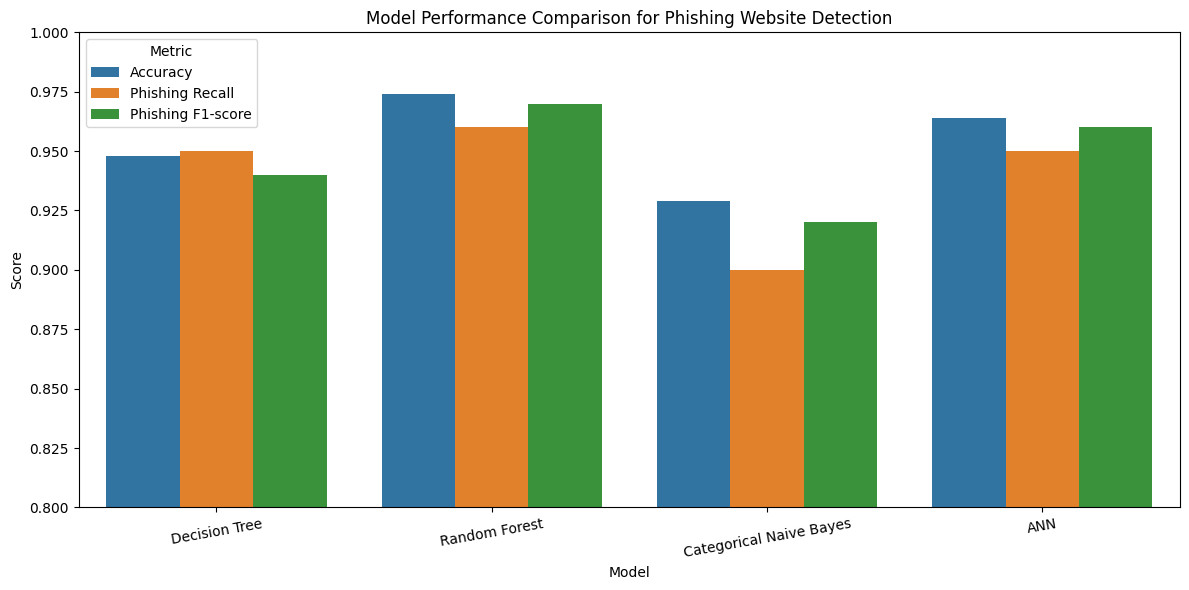

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Categorical Naive Bayes",
        "ANN"
    ],
    "Accuracy": [0.9480, 0.9742, 0.9290, 0.9638],
    "Phishing Recall": [0.95, 0.96, 0.90, 0.95],
    "Phishing F1-score": [0.94, 0.97, 0.92, 0.96],
    "Missed Phishing Sites": [52, 36, 95, 51]
})

display(results)

plot_data = results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Phishing Recall", "Phishing F1-score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison for Phishing Website Detection")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=10)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

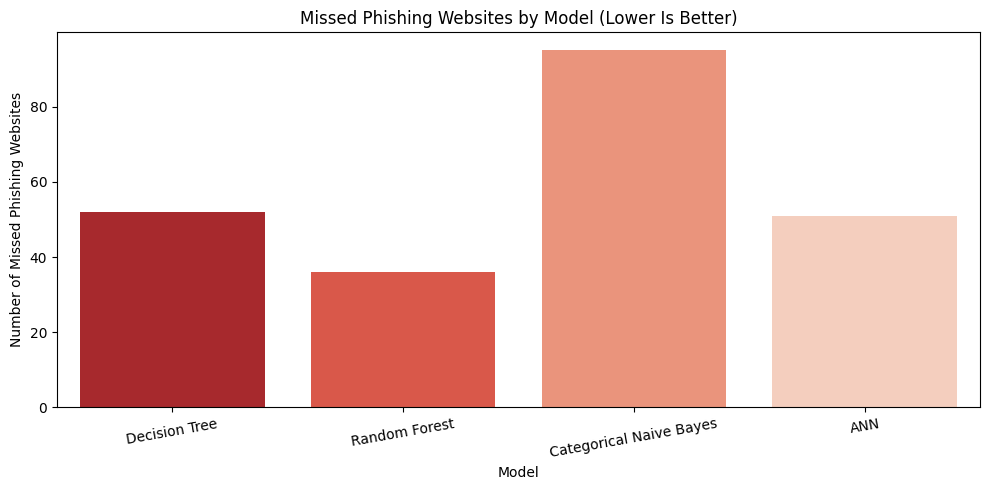

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Missed Phishing Sites",
    hue="Model",
    palette="Reds_r",
    legend=False
)

plt.title("Missed Phishing Websites by Model (Lower Is Better)")
plt.xlabel("Model")
plt.ylabel("Number of Missed Phishing Websites")
plt.xticks(rotation=10)
plt.tight_layout()

plt.savefig("missed_phishing_sites.png", dpi=300, bbox_inches="tight")
plt.show()